# QAT + Dynamic Quantization
## Lung Cancer Classification (CNN + Attention + SVM)

### Konsep Gabungan:
1. **QAT (Quantization-Aware Training)** – Fine-tune model dengan *fake quantization*  
   agar bobot menjadi robust terhadap quantization error.
2. **Dynamic Quantization** – Konversi TFLite **tanpa** `representative_dataset`:  
   bobot di-quantize secara *offline*, aktivasi di-quantize secara *online* saat runtime.

### Kenapa QAT + Dynamic?
| | Static PTQ | QAT Static | **QAT Dynamic** |
|---|---|---|---|
| Representative dataset | ✅ Required | ✅ Required | ❌ **Not needed** |
| Fine-tuning | ❌ No | ✅ Yes | ✅ **Yes** |
| Activation quantization | Offline (fixed) | Offline (fixed) | **Online (per-batch)** |
| Setup complexity | Medium | High | **Medium** |
| Accuracy | Good | Better | **Good-Better** |

### Dua varian yang diuji:
- **QAT FP16 Dynamic** – Fine-tune → convert FP16, tanpa calibration dataset
- **QAT INT8 Dynamic** – Fine-tune dengan fake-quant → convert INT8, tanpa calibration dataset

> ⚠️ **Perbedaan kunci vs `qat.ipynb` (static)**:  
> File `qat.ipynb` menggunakan `representative_dataset` dan `TFLITE_BUILTINS_INT8` (static).  
> Notebook ini **tidak** menggunakan keduanya (dynamic).

## 1. Setup Environment

> ⚠️ **Wajib dijalankan pertama** sebelum import TensorFlow apapun.

In [1]:
import os
# CRITICAL: must be set BEFORE importing tensorflow
os.environ["TF_USE_LEGACY_KERAS"] = "1"
print("✅ TF_USE_LEGACY_KERAS=1 set")


✅ TF_USE_LEGACY_KERAS=1 set


## 2. Imports

In [2]:
import time, json, shutil
from datetime import datetime
import numpy as np
import pandas as pd
import joblib
import cv2
import tensorflow as tf
import tf_keras
from tf_keras.models import Model
from tf_keras.layers import (Layer, Conv2D, MaxPooling2D, Flatten, Dense,
                             GlobalAveragePooling2D, Reshape, Multiply, Input)
from tf_keras.callbacks import EarlyStopping
from tf_keras.utils import to_categorical
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
import tensorflow_model_optimization as tfmot
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"tf_keras   : {tf_keras.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU'))} device(s)")



TensorFlow : 2.21.0
tf_keras   : 2.21.0
GPU        : 0 device(s)


## 3. Custom Layer

In [3]:
class ChannelAttention(Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        ch = input_shape[-1]
        self.gap     = GlobalAveragePooling2D()
        self.dense1  = Dense(max(1, ch // self.ratio), activation="relu")
        self.dense2  = Dense(ch, activation="sigmoid")
        self.reshape = Reshape((1, 1, ch))
        super().build(input_shape)

    def call(self, x):
        a = self.gap(x)
        a = self.dense1(a)
        a = self.dense2(a)
        a = self.reshape(a)
        return Multiply()([x, a])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"ratio": self.ratio})
        return cfg

CUSTOM_OBJECTS = {"ChannelAttention": ChannelAttention}
print("✅ ChannelAttention defined")


✅ ChannelAttention defined


## 4. Architecture Builder (tf_keras)

> ⚠️ **Sesuaikan** fungsi ini dengan arsitektur model Anda yang sebenarnya.

In [4]:
def build_model_tfkeras(input_shape=(224, 224, 3), num_classes=3):
    """
    Rebuild arsitektur menggunakan tf_keras (Keras 2.x).
    UPDATE sesuai model Anda jika arsitektur berbeda!
    """
    inputs = Input(shape=input_shape)

    # Stage 1
    x = Conv2D(64, 3, padding="same", activation="relu")(inputs)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D(2)(x)

    # Stage 2
    x = Conv2D(32, 3, padding="same", activation="relu")(x)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D(2)(x)

    # Feature layer
    x        = Flatten()(x)
    features = Dense(16, activation="relu", name="feature_layer")(x)
    output   = Dense(num_classes, activation="softmax", name="softmax_output")(features)

    return Model(inputs, output, name="CNN_Attention_tfkeras")

print("✅ Architecture function defined")


✅ Architecture function defined


## 5. Helper Functions

In [5]:
def get_size_kb(path):
    return os.path.getsize(path) / 1024 if os.path.exists(path) else 0.0


class TFLiteExtractor:
    """Wrapper TFLite agar mirip interface Keras .predict()"""
    def __init__(self, path):
        self.interp = tf.lite.Interpreter(model_path=path)
        self.interp.allocate_tensors()
        self.inp = self.interp.get_input_details()
        self.out = self.interp.get_output_details()

    def predict(self, X, verbose=0, batch_size=None):
        feats = []
        for img in X:
            self.interp.set_tensor(self.inp[0]['index'],
                                   img[np.newaxis].astype(np.float32))
            self.interp.invoke()
            feats.append(self.interp.get_tensor(self.out[0]['index'])[0])
        return np.array(feats)


def evaluate_model(extractor, svm, scaler, X, y_true, class_names, label):
    t0        = time.time()
    feats     = extractor.predict(X, verbose=0, batch_size=16)
    feat_time = time.time() - t0

    t0      = time.time()
    X_sc    = scaler.transform(feats)
    y_pred  = svm.predict(X_sc)
    y_prob  = svm.predict_proba(X_sc)
    inf_time = time.time() - t0

    acc  = accuracy_score(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)
    rep  = classification_report(y_true, y_pred,
                                  target_names=class_names, output_dict=True)
    sens = rep['macro avg']['recall']
    prec = rep['macro avg']['precision']
    f1   = rep['macro avg']['f1-score']

    specs = []
    for i in range(len(class_names)):
        tn = cm.sum() - cm[i,:].sum() - cm[:,i].sum() + cm[i,i]
        fp = cm[:,i].sum() - cm[i,i]
        specs.append(tn/(tn+fp) if (tn+fp)>0 else 0)
    spec = np.mean(specs)

    y_bin = label_binarize(y_true, classes=range(len(class_names)))
    auc   = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')

    return dict(label=label, accuracy=acc, sensitivity=sens, specificity=spec,
                precision=prec, f1=f1, auc=auc, cm=cm,
                feat_time=feat_time, inf_time=inf_time)


def make_concrete_fn(keras_model):
    """Buat concrete function untuk TFLite conversion"""
    in_shape = tuple(keras_model.input_shape)
    spec     = tf.TensorSpec(shape=in_shape, dtype=tf.float32, name="input")

    class _Wrap(tf.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        @tf.function(input_signature=[spec])
        def __call__(self, x):
            return self.m(x, training=False)

    wrapper  = _Wrap(keras_model)
    concrete = wrapper.__call__.get_concrete_function()
    return concrete, wrapper


def load_weights_from_keras3(tfk_model, keras_path):
    """Transfer weights dari file Keras 3.x (.keras) ke model tf_keras"""
    import zipfile, tempfile, h5py
    with zipfile.ZipFile(keras_path, 'r') as z:
        with tempfile.TemporaryDirectory() as tmpdir:
            z.extract('model.weights.h5', tmpdir)
            h5_path = os.path.join(tmpdir, 'model.weights.h5')
            tfk_layers = [l for l in tfk_model.layers if l.weights]

            with h5py.File(h5_path, 'r') as f:
                if 'layers' not in f:
                    return
                k3_names = sorted(f['layers'].keys())
                used     = set()

                for lyr in tfk_layers:
                    target_shapes = [w.shape for w in lyr.get_weights()]

                    def collect(grp):
                        res = []
                        if 'vars' in grp:
                            for v in sorted(grp['vars'].keys()):
                                res.append(np.array(grp['vars'][v]))
                        for k in sorted(grp.keys()):
                            if k != 'vars' and isinstance(grp[k], h5py.Group):
                                res.extend(collect(grp[k]))
                        return res

                    for nm in k3_names:
                        if nm in used:
                            continue
                        w_list = collect(f['layers'][nm])
                        if [w.shape for w in w_list] == target_shapes:
                            lyr.set_weights(w_list)
                            used.add(nm)
                            break

    print(f"  ✅ Weights loaded from {os.path.basename(keras_path)}")


print("✅ Helper functions defined")


def get_total_size_kb(*paths):
    """Total size semua file: model/TFLite + SVM + scaler"""
    return sum(os.path.getsize(p) / 1024 for p in paths if os.path.exists(p))


✅ Helper functions defined


## 6. Load Dataset

In [6]:
print("=" * 70)
print("LOADING DATASET")
print("=" * 70)

# Auto-detect dataset path
SCRIPT_DIR = os.getcwd()
for candidate in [
    os.path.join(os.path.dirname(SCRIPT_DIR), "dataset_processed2"),
    "../dataset_processed2",
    "dataset_processed2",
]:
    if os.path.exists(candidate):
        dataset_base_path = candidate
        break

IMG_SIZE    = 224
categories  = ["Bengin cases", "Malignant cases", "Normal cases"]
class_names = ["Bengin", "Malignant", "Normal"]

def load_split(split):
    X, y = [], []
    for idx, cat in enumerate(categories):
        cat_path = os.path.join(dataset_base_path, split, cat)
        if not os.path.isdir(cat_path):
            continue
        for fn in sorted(os.listdir(cat_path)):
            if not fn.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img = cv2.imread(os.path.join(cat_path, fn))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img.astype(np.float32) / 255.0)
            y.append(idx)
    return np.array(X, dtype=np.float32), np.array(y)

print("Loading …")
X_train, y_train_int = load_split("train")
X_valid, y_valid_int = load_split("valid")
X_test,  y_test_int  = load_split("test")

y_train = to_categorical(y_train_int, 3)
y_valid = to_categorical(y_valid_int, 3)

print(f"Train : {X_train.shape}")
print(f"Valid : {X_valid.shape}")
print(f"Test  : {X_test.shape}")
print("\nClass distribution (train):")
for i, nm in enumerate(class_names):
    n = np.sum(y_train_int == i)
    print(f"  {nm:<12}: {n:4d} ({n/len(y_train_int)*100:5.1f}%)")


LOADING DATASET
Loading …
Train : (737, 224, 224, 3)
Valid : (158, 224, 224, 3)
Test  : (159, 224, 224, 3)

Class distribution (train):
  Bengin      :   71 (  9.6%)
  Malignant   :  383 ( 52.0%)
  Normal      :  283 ( 38.4%)


## 7. Load Baseline Model

> ⚠️ **Update `ORIG_FOLDER`** sesuai direktori hasil training Anda.

In [7]:
print("=" * 70)
print("LOADING BASELINE MODEL")
print("=" * 70)

# ⚠️ UPDATE THIS PATH ──────────────────────────────────────────────────────────
ORIG_FOLDER = "saved_models_original"

if not os.path.isdir(ORIG_FOLDER):
    raise FileNotFoundError(
        f"Folder '{ORIG_FOLDER}' tidak ditemukan. "
        "Update ORIG_FOLDER atau jalankan training terlebih dahulu."
    )

cnn_path    = os.path.join(ORIG_FOLDER, "cnn_attention_model.keras")
svm_path    = os.path.join(ORIG_FOLDER, "svm_classifier.pkl")
scaler_path = os.path.join(ORIG_FOLDER, "feature_scaler.pkl")

# Build tf_keras model & transfer weights
print("Building tf_keras model …")
model_orig = build_model_tfkeras((IMG_SIZE, IMG_SIZE, 3), 3)
_ = model_orig(X_train[:1])   # build weights
load_weights_from_keras3(model_orig, cnn_path)

extractor_orig = Model(model_orig.input,
                       model_orig.get_layer("feature_layer").output)

svm_orig    = joblib.load(svm_path)
scaler_orig = joblib.load(scaler_path)

print(f"✅ Loaded  |  Params: {model_orig.count_params():,}")

print("\nEvaluating baseline …")
metrics_orig = evaluate_model(extractor_orig, svm_orig, scaler_orig,
                               X_test, y_test_int, class_names, "Baseline (FP32)")
print(f"✅ Baseline Accuracy: {metrics_orig['accuracy']:.4f}")


LOADING BASELINE MODEL
Building tf_keras model …


  ✅ Weights loaded from cnn_attention_model.keras
✅ Loaded  |  Params: 1,627,343

Evaluating baseline …
✅ Baseline Accuracy: 0.9937


## 8. Konsep QAT + Dynamic Quantization

### Alur Pipeline:
```
Baseline FP32
    │
    ▼ Fine-tune dengan fake quantization (QAT)
Model QAT (FP32, tapi weight sudah robust terhadap quantization)
    │
    ├──► Convert FP16 Dynamic  (TANPA representative_dataset)
    │         ─ Weights: FP16 (offline)
    │         ─ Activations: FP32 (no quantization)
    │
    └──► Convert INT8 Dynamic  (TANPA representative_dataset)
              ─ Weights: INT8 (offline)
              ─ Activations: diquantize ONLINE per-batch saat runtime
```

### Perbedaan dengan qat.ipynb (Static):
```python
# qat.ipynb – STATIC
converter.representative_dataset = rep_data          # ← Ada!
converter.target_spec.supported_ops = [TFLITE_BUILTINS_INT8]
# → Activations: scale FIXED dari calibration

# qat_dynamic.ipynb – DYNAMIC (notebook ini)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # ← Hanya ini!
# → TIDAK ada representative_dataset
# → Activations: scale dihitung SAAT RUNTIME
```

## 9. QAT Fine-Tuning (Shared untuk FP16 & INT8)

Fine-tune **satu model** dengan fake quantization, lalu digunakan untuk  
konversi ke FP16 Dynamic maupun INT8 Dynamic.

In [8]:
print("=" * 70)
print("QAT FINE-TUNING")
print("=" * 70)

# Build fresh model & load weights
model_qat = build_model_tfkeras((IMG_SIZE, IMG_SIZE, 3), 3)
_ = model_qat(X_train[:1])
load_weights_from_keras3(model_qat, cnn_path)

# ── Apply fake quantization annotation ───────────────────────────────────────
qal   = tfmot.quantization.keras.quantize_annotate_layer
q_app = tfmot.quantization.keras.quantize_apply
q_scp = tfmot.quantization.keras.quantize_scope

def annotate_fn(layer):
    if isinstance(layer, (Conv2D, Dense, MaxPooling2D, Flatten)):
        return qal(layer)
    return layer

annotated = tf_keras.models.clone_model(model_qat, clone_function=annotate_fn)
with q_scp({"ChannelAttention": ChannelAttention}):
    model_qat = q_app(annotated)

model_qat.compile(
    optimizer=tf_keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning dengan fake quantization (5 epochs) …")
history = model_qat.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=5,
    batch_size=8,
    verbose=1
)
print("✅ QAT fine-tuning selesai")


QAT FINE-TUNING
  ✅ Weights loaded from cnn_attention_model.keras
Fine-tuning dengan fake quantization (5 epochs) …
Epoch 1/5


93/93 [==============================] - 20s 205ms/step - loss: 0.2691 - accuracy: 0.9159 - val_loss: 0.1398 - val_accuracy: 0.9810
Epoch 2/5
93/93 [==============================] - 19s 203ms/step - loss: 0.1003 - accuracy: 0.9891 - val_loss: 0.0876 - val_accuracy: 0.9747
Epoch 3/5
93/93 [==============================] - 20s 212ms/step - loss: 0.0601 - accuracy: 0.9959 - val_loss: 0.0690 - val_accuracy: 0.9873
Epoch 4/5
93/93 [==============================] - 21s 223ms/step - loss: 0.0421 - accuracy: 0.9959 - val_loss: 0.0590 - val_accuracy: 0.9937
Epoch 5/5
93/93 [==============================] - 21s 223ms/step - loss: 0.0323 - accuracy: 0.9973 - val_loss: 0.0553 - val_accuracy: 0.9937
✅ QAT fine-tuning selesai


### Training History

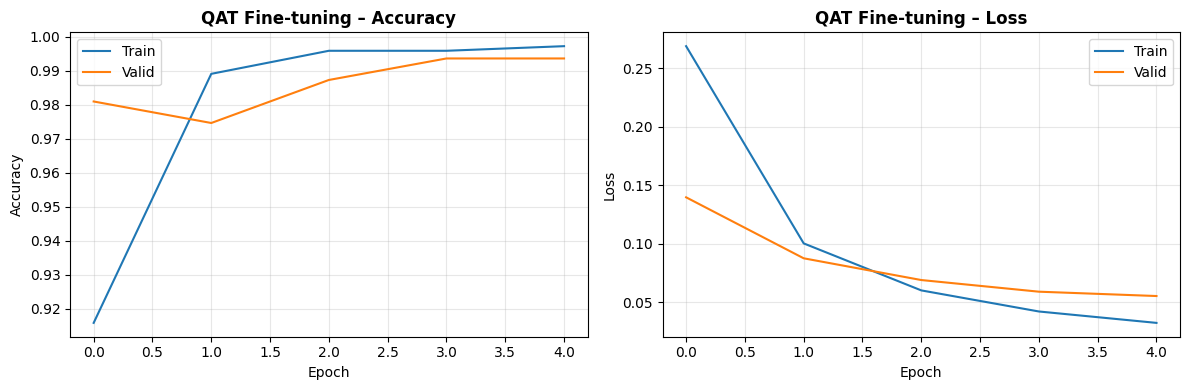

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Valid')
axes[0].set_title("QAT Fine-tuning – Accuracy", fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Valid')
axes[1].set_title("QAT Fine-tuning – Loss", fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Convert → FP16 Dynamic

Konversi extractor dari model QAT ke TFLite FP16 **tanpa** `representative_dataset`.

```python
# Dynamic: hanya optimizer, tanpa calibration dataset
converter.optimizations         = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
# ← TIDAK ada representative_dataset
```

In [10]:
print("=" * 70)
print("QAT FP16 DYNAMIC CONVERSION")
print("=" * 70)

# Strip pruning wrappers & extract feature layer
model_qat_stripped = tfmot.quantization.keras.strip_pruning(model_qat)     if hasattr(tfmot.quantization.keras, 'strip_pruning') else model_qat

# Cari nama layer feature_layer (mungkin ada prefix "quant_")
feat_layer_name = None
for lyr in model_qat.layers:
    if "feature_layer" in lyr.name:
        feat_layer_name = lyr.name
        break

print(f"Feature layer name: {feat_layer_name}")

extractor_qat_fp16 = Model(model_qat.input,
                            model_qat.get_layer(feat_layer_name).output)

# ── Concrete function ─────────────────────────────────────────────────────────
concrete_fp16, wrapper_fp16 = make_concrete_fn(extractor_qat_fp16)

# ── Converter – DYNAMIC (tidak ada representative_dataset) ───────────────────
conv_fp16 = tf.lite.TFLiteConverter.from_concrete_functions(
    [concrete_fp16], wrapper_fp16)
conv_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
conv_fp16.target_spec.supported_types = [tf.float16]
# ← TIDAK ada representative_dataset  ← kunci dynamic!

tflite_fp16 = conv_fp16.convert()

os.makedirs("artifacts", exist_ok=True)
path_fp16 = "artifacts/qat_dynamic_fp16.tflite"
with open(path_fp16, "wb") as f:
    f.write(tflite_fp16)

size_fp16 = len(tflite_fp16) / 1024
print(f"✅ QAT FP16 Dynamic saved  |  Size: {size_fp16:.2f} KB")

# Verifikasi dtype
chk = tf.lite.Interpreter(model_path=path_fp16)
chk.allocate_tensors()
print(f"   Input  dtype : {chk.get_input_details()[0]['dtype']}")
print(f"   Output dtype : {chk.get_output_details()[0]['dtype']}")


QAT FP16 DYNAMIC CONVERSION
Feature layer name: quant_feature_layer
INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpjmvwu17s\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpjmvwu17s\assets


✅ QAT FP16 Dynamic saved  |  Size: 6364.10 KB
   Input  dtype : <class 'numpy.float32'>
   Output dtype : <class 'numpy.float32'>


d:\bintang\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### Train SVM – FP16 Dynamic Features

In [11]:
print("Extracting FP16 dynamic features …")
ex_fp16    = TFLiteExtractor(path_fp16)
X_tr_fp16  = ex_fp16.predict(X_train)
X_val_fp16 = ex_fp16.predict(X_valid)

scaler_fp16 = StandardScaler()
X_sc_fp16   = scaler_fp16.fit_transform(np.vstack([X_tr_fp16, X_val_fp16]))
y_comb      = np.concatenate([y_train_int, y_valid_int])

print("Training SVM (C=1.0, gamma='scale') …")
svm_fp16 = SVC(kernel='rbf', C=1.0, gamma='scale',
               probability=True, random_state=SEED)
svm_fp16.fit(X_sc_fp16, y_comb)

metrics_fp16 = evaluate_model(ex_fp16, svm_fp16, scaler_fp16,
                               X_test, y_test_int, class_names, "QAT FP16 Dynamic")
print(f"✅ QAT FP16 Dynamic Accuracy: {metrics_fp16['accuracy']:.4f}")


Extracting FP16 dynamic features …
Training SVM (C=1.0, gamma='scale') …
✅ QAT FP16 Dynamic Accuracy: 0.9874


## 11. Convert → INT8 Dynamic

Konversi extractor dari model QAT ke TFLite INT8 **tanpa** `representative_dataset`.

```python
# Dynamic INT8: hanya optimizer
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# ← TIDAK ada representative_dataset
# ← TIDAK ada target_spec.supported_ops = TFLITE_BUILTINS_INT8
# → Weights: INT8 (offline), Activations: quantized ONLINE saat runtime
```

In [12]:
print("=" * 70)
print("QAT INT8 DYNAMIC CONVERSION")
print("=" * 70)

extractor_qat_int8 = Model(model_qat.input,
                            model_qat.get_layer(feat_layer_name).output)

concrete_int8, wrapper_int8 = make_concrete_fn(extractor_qat_int8)

# ── Converter – DYNAMIC INT8 ──────────────────────────────────────────────────
conv_int8 = tf.lite.TFLiteConverter.from_concrete_functions(
    [concrete_int8], wrapper_int8)
conv_int8.optimizations = [tf.lite.Optimize.DEFAULT]
# ← TIDAK ada representative_dataset
# ← TIDAK ada supported_ops INT8

tflite_int8 = conv_int8.convert()

path_int8 = "artifacts/qat_dynamic_int8.tflite"
with open(path_int8, "wb") as f:
    f.write(tflite_int8)

size_int8 = len(tflite_int8) / 1024
print(f"✅ QAT INT8 Dynamic saved  |  Size: {size_int8:.2f} KB")

# Verifikasi dtype
chk2 = tf.lite.Interpreter(model_path=path_int8)
chk2.allocate_tensors()
print(f"   Input  dtype : {chk2.get_input_details()[0]['dtype']}")   # float32 (dynamic)
print(f"   Output dtype : {chk2.get_output_details()[0]['dtype']}")  # float32 (dynamic)


QAT INT8 DYNAMIC CONVERSION
INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpftmkq97g\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpftmkq97g\assets


✅ QAT INT8 Dynamic saved  |  Size: 6364.09 KB
   Input  dtype : <class 'numpy.float32'>
   Output dtype : <class 'numpy.float32'>


d:\bintang\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### Train SVM – INT8 Dynamic Features

In [13]:
print("Extracting INT8 dynamic features …")
ex_int8    = TFLiteExtractor(path_int8)
X_tr_int8  = ex_int8.predict(X_train)
X_val_int8 = ex_int8.predict(X_valid)

scaler_int8 = StandardScaler()
X_sc_int8   = scaler_int8.fit_transform(np.vstack([X_tr_int8, X_val_int8]))

print("Training SVM (C=1.0, gamma='scale') …")
svm_int8 = SVC(kernel='rbf', C=1.0, gamma='scale',
               probability=True, random_state=SEED)
svm_int8.fit(X_sc_int8, y_comb)

metrics_int8 = evaluate_model(ex_int8, svm_int8, scaler_int8,
                               X_test, y_test_int, class_names, "QAT INT8 Dynamic")
print(f"✅ QAT INT8 Dynamic Accuracy: {metrics_int8['accuracy']:.4f}")


Extracting INT8 dynamic features …
Training SVM (C=1.0, gamma='scale') …
✅ QAT INT8 Dynamic Accuracy: 0.9874


## 12. Save Artifacts

In [14]:
print("=" * 70)
print("SAVING ARTIFACTS")
print("=" * 70)

timestamp   = datetime.now().strftime('%Y%m%d_%H%M%S')
save_folder = f"saved_models_qat_dynamic_{timestamp}"
os.makedirs(save_folder, exist_ok=True)

# TFLite models
shutil.copy2(path_fp16, os.path.join(save_folder, "qat_dynamic_fp16.tflite"))
shutil.copy2(path_int8, os.path.join(save_folder, "qat_dynamic_int8.tflite"))

# SVM & scalers
joblib.dump(svm_fp16,    os.path.join(save_folder, "svm_fp16.pkl"))
joblib.dump(scaler_fp16, os.path.join(save_folder, "scaler_fp16.pkl"))
joblib.dump(svm_int8,    os.path.join(save_folder, "svm_int8.pkl"))
joblib.dump(scaler_int8, os.path.join(save_folder, "scaler_int8.pkl"))

# Baseline reference
model_orig.save(os.path.join(save_folder, "baseline.keras"))
joblib.dump(svm_orig,    os.path.join(save_folder, "svm_baseline.pkl"))
joblib.dump(scaler_orig, os.path.join(save_folder, "scaler_baseline.pkl"))

print(f"✅ Saved to: {save_folder}/")


SAVING ARTIFACTS
✅ Saved to: saved_models_qat_dynamic_20260519_131402/


## 13. Comprehensive Comparison Table

Semua metrik: **Accuracy, Sensitivity, Specificity, Precision, F1-Score, AUC,  
Feat Ext (ms), SVM Inf (ms), Total (ms)**

In [19]:
# ============================================================================
# COMPARISON TABLE
# ============================================================================
print("\n" + "="*70)
print("COMPARISON TABLE")
print("="*70)

all_results = [metrics_orig, metrics_fp16, metrics_int8]

# Baseline size mengikuti notebook referensi: ukuran file Keras asli
size_baseline = get_size_kb(cnn_path)

sizes = [size_baseline, size_fp16, size_int8]

comp_data = []
for m, sz in zip(all_results, sizes):
    comp_data.append({
        "Model"         : m['label'],
        "Size (KB)"     : f"{sz:.2f}",
        "Compression"   : f"{sizes[0]/sz:.2f}x",
        "Accuracy"      : f"{m['accuracy']:.4f}",
        "Sensitivity"   : f"{m['sensitivity']:.4f}",
        "Specificity"   : f"{m['specificity']:.4f}",
        "Precision"     : f"{m['precision']:.4f}",
        "F1-Score"      : f"{m['f1']:.4f}",
        "AUC"           : f"{m['auc']:.4f}",
        "Feat Ext (ms)" : f"{m['feat_time']*1000:.2f}",
        "SVM Inf (ms)"  : f"{m['inf_time']*1000:.2f}",
        "Total (ms)"    : f"{(m['feat_time']+m['inf_time'])*1000:.2f}",
    })

df_comp = pd.DataFrame(comp_data)
print("\n" + df_comp.to_string(index=False))

df_comp.to_csv(os.path.join(save_folder, "comparison.csv"), index=False)

summary = {}
for i, (m, sz) in enumerate(zip(all_results, sizes)):
    key = m['label'].lower().replace(' ','_').replace('(','').replace(')','')
    summary[key] = {
        'accuracy'       : float(m['accuracy']),
        'sensitivity'    : float(m['sensitivity']),
        'specificity'    : float(m['specificity']),
        'precision'      : float(m['precision']),
        'f1'             : float(m['f1']),
        'auc'            : float(m['auc']),
        'size_kb'        : float(sz),
        'feat_time_ms'   : float(m['feat_time']*1000),
        'inf_time_ms'    : float(m['inf_time']*1000),
        'total_time_ms'  : float((m['feat_time']+m['inf_time'])*1000),
        'degradation_pct': float((all_results[0]['accuracy']-m['accuracy'])
                                  /all_results[0]['accuracy']*100) if i>0 else 0.0,
        'speedup'        : float((all_results[0]['feat_time']+all_results[0]['inf_time'])
                                  /(m['feat_time']+m['inf_time'])),
    }
with open(os.path.join(save_folder, "summary.json"), 'w') as f:
    json.dump(summary, f, indent=2)
print("\n✅ comparison.csv & summary.json saved")



COMPARISON TABLE

           Model Size (KB) Compression Accuracy Sensitivity Specificity Precision F1-Score    AUC Feat Ext (ms) SVM Inf (ms) Total (ms)
 Baseline (FP32)  19138.72       1.00x   0.9937      0.9945      0.9977    0.9804   0.9871 1.0000        942.77         1.01     943.78
QAT FP16 Dynamic   6364.10       3.01x   0.9874      0.9905      0.9953    0.9630   0.9756 1.0000       1478.06         0.00    1478.06
QAT INT8 Dynamic   6364.09       3.01x   0.9874      0.9905      0.9953    0.9630   0.9756 1.0000       1578.60         1.01    1579.61

✅ comparison.csv & summary.json saved


## 14. Visualizations

CREATING VISUALIZATIONS
✅ comparison_plots.png saved


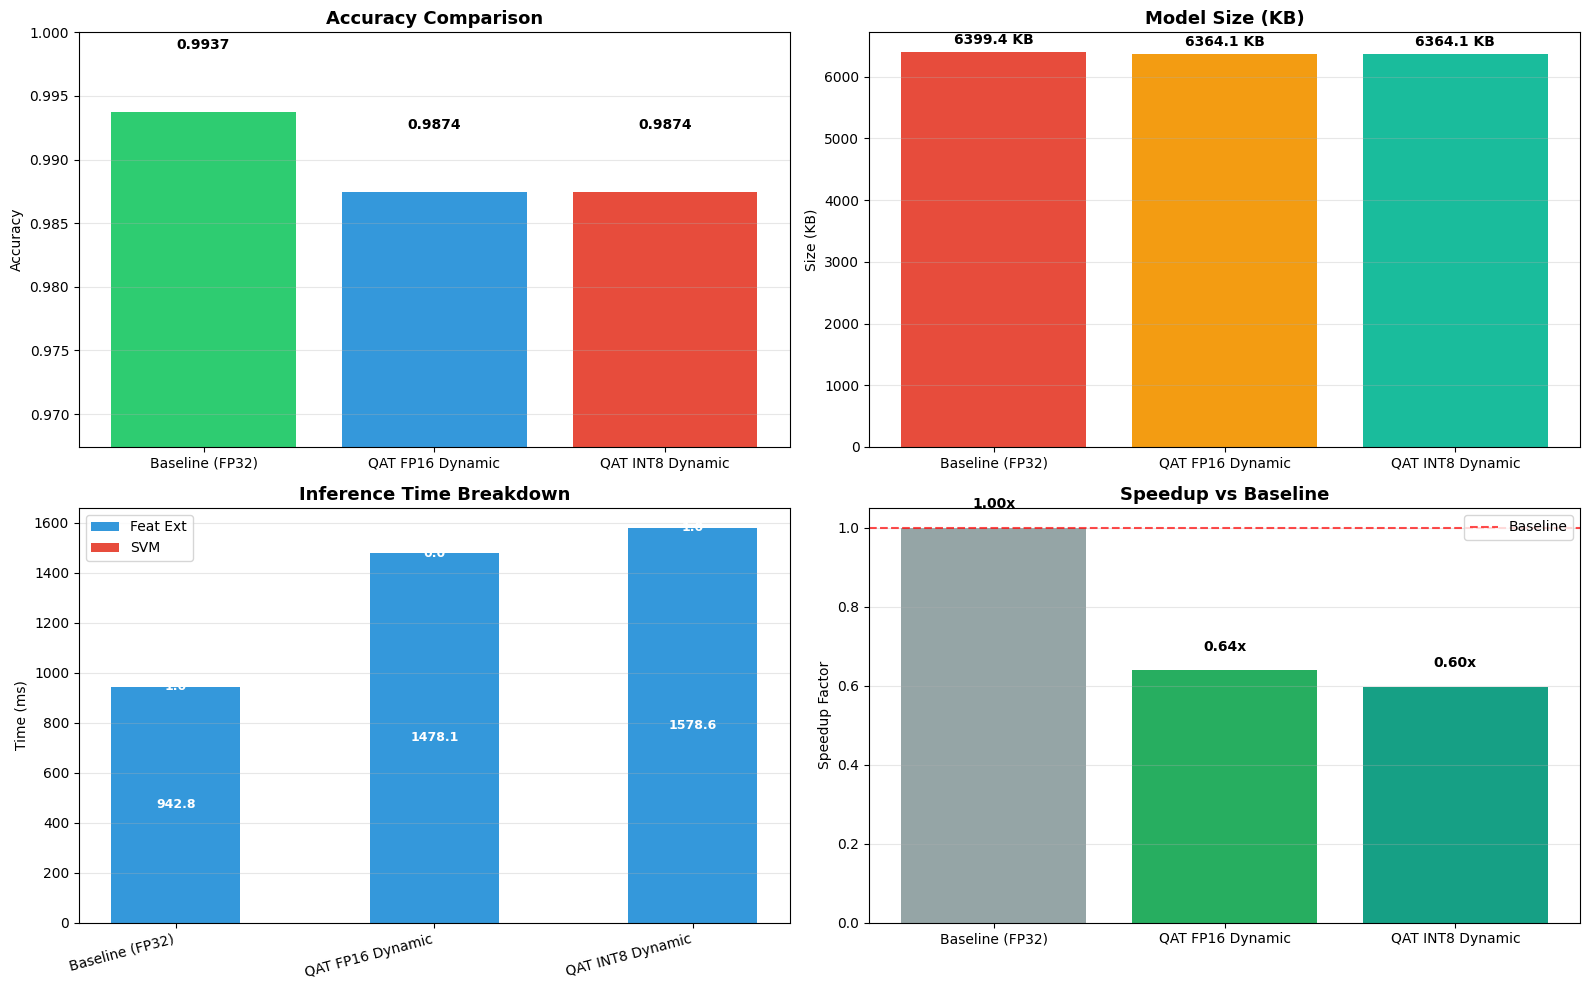

✅ confusion_matrices.png saved


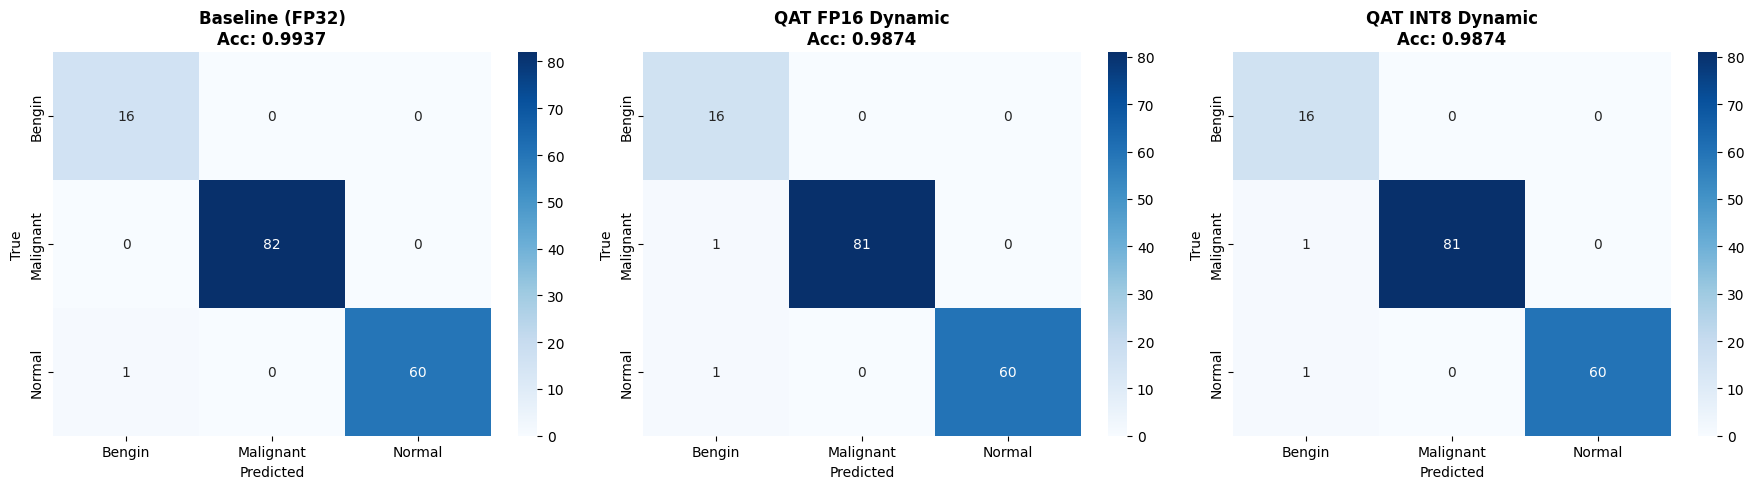

In [16]:
print("=" * 70)
print("CREATING VISUALIZATIONS")
print("=" * 70)

labels  = [m['label'] for m in all_results]
colors3 = ['#2ecc71', '#3498db', '#e74c3c']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Accuracy
acc_vals = [m['accuracy'] for m in all_results]
bars = axes[0,0].bar(labels, acc_vals, color=colors3)
axes[0,0].set_ylim(min(acc_vals)-0.02, 1.0)
axes[0,0].set_title("Accuracy Comparison", fontsize=13, fontweight='bold')
axes[0,0].set_ylabel("Accuracy")
axes[0,0].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, acc_vals):
    axes[0,0].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.005, f'{v:.4f}',
                   ha='center', fontweight='bold')

# 2. Model Size
bars = axes[0,1].bar(labels, sizes, color=['#e74c3c','#f39c12','#1abc9c'])
axes[0,1].set_title("Model Size (KB)", fontsize=13, fontweight='bold')
axes[0,1].set_ylabel("Size (KB)")
axes[0,1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, sizes):
    axes[0,1].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+max(sizes)*0.02,
                   f'{v:.1f} KB', ha='center', fontweight='bold')

# 3. Inference Time (Stacked bar)
feat_t = [m['feat_time']*1000 for m in all_results]
svm_t  = [m['inf_time']*1000  for m in all_results]
x      = np.arange(len(labels))
b1 = axes[1,0].bar(x, feat_t, 0.5, label='Feat Ext', color='#3498db')
b2 = axes[1,0].bar(x, svm_t,  0.5, bottom=feat_t,    label='SVM',     color='#e74c3c')
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(labels, rotation=15, ha='right')
axes[1,0].set_ylabel('Time (ms)')
axes[1,0].set_title('Inference Time Breakdown', fontsize=13, fontweight='bold')
axes[1,0].legend(); axes[1,0].grid(axis='y', alpha=0.3)
for i, (f, s) in enumerate(zip(feat_t, svm_t)):
    axes[1,0].text(i, f/2,   f'{f:.1f}', ha='center', va='center',
                   color='white', fontweight='bold', fontsize=9)
    axes[1,0].text(i, f+s/2, f'{s:.1f}', ha='center', va='center',
                   color='white', fontweight='bold', fontsize=9)

# 4. Speedup
total_t  = [f+s for f,s in zip(feat_t, svm_t)]
speedups = [total_t[0]/t for t in total_t]
bars = axes[1,1].bar(labels, speedups, color=['#95a5a6','#27ae60','#16a085'])
axes[1,1].axhline(1.0, color='red', linestyle='--', alpha=0.7, label='Baseline')
axes[1,1].set_title('Speedup vs Baseline', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Speedup Factor')
axes[1,1].legend(); axes[1,1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, speedups):
    axes[1,1].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.05, f'{v:.2f}x',
                   ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_folder, "comparison_plots.png"),
            dpi=150, bbox_inches='tight')
print("✅ comparison_plots.png saved")
plt.show(); plt.close()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, all_results):
    sns.heatmap(m['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f"{m['label']}\nAcc: {m['accuracy']:.4f}", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(save_folder, "confusion_matrices.png"),
            dpi=150, bbox_inches='tight')
print("✅ confusion_matrices.png saved")
plt.show(); plt.close()


## 15. Final Summary

In [17]:
print("\n" + "=" * 70)
print("QAT + DYNAMIC QUANTIZATION COMPLETE!")
print("=" * 70)
print(f"\n📁 Saved to: {save_folder}/")
print("\n📊 Summary:")
for i, (m, sz) in enumerate(zip(all_results, sizes)):
    deg     = (all_results[0]['accuracy']-m['accuracy'])/all_results[0]['accuracy']*100
    speedup = ((all_results[0]['feat_time']+all_results[0]['inf_time'])
               /(m['feat_time']+m['inf_time']))
    print(f"\n{m['label']}:")
    print(f"  Accuracy   : {m['accuracy']:.4f}  ({deg:+.2f}% vs baseline)")
    print(f"  Size       : {sz:.2f} KB  ({size_baseline/sz:.2f}x compression)")
    print(f"  Total time : {(m['feat_time']+m['inf_time'])*1000:.2f} ms  ({speedup:.2f}x speedup)")

print("\n📁 Files:")
for fn in sorted(os.listdir(save_folder)):
    print(f"   - {save_folder}/{fn}")
print("=" * 70)



QAT + DYNAMIC QUANTIZATION COMPLETE!

📁 Saved to: saved_models_qat_dynamic_20260519_131402/

📊 Summary:

Baseline (FP32):
  Accuracy   : 0.9937  (+0.00% vs baseline)
  Size       : 6399.42 KB  (1.00x compression)
  Total time : 943.78 ms  (1.00x speedup)

QAT FP16 Dynamic:
  Accuracy   : 0.9874  (+0.63% vs baseline)
  Size       : 6364.10 KB  (1.01x compression)
  Total time : 1478.06 ms  (0.64x speedup)

QAT INT8 Dynamic:
  Accuracy   : 0.9874  (+0.63% vs baseline)
  Size       : 6364.09 KB  (1.01x compression)
  Total time : 1579.61 ms  (0.60x speedup)

📁 Files:
   - saved_models_qat_dynamic_20260519_131402/baseline.keras
   - saved_models_qat_dynamic_20260519_131402/comparison.csv
   - saved_models_qat_dynamic_20260519_131402/comparison_plots.png
   - saved_models_qat_dynamic_20260519_131402/confusion_matrices.png
   - saved_models_qat_dynamic_20260519_131402/qat_dynamic_fp16.tflite
   - saved_models_qat_dynamic_20260519_131402/qat_dynamic_int8.tflite
   - saved_models_qat_dynamic_